In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [ ]:
skolky_venkov = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
skolky_mesto = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")

skolky_body = pd.concat(
    [skolky_venkov, skolky_mesto]
)


In [20]:
 skolky_body = skolky_body.drop(columns=["index_right"])

In [14]:
#skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
obce_polygony = gpd.read_file("geometrie/obce_slbd.geojson").to_crs(5514)
obce_polygony = obce_polygony[["geometry","celkem", "Kód_obce"]]

In [21]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [22]:
#obce_skolky= gpd.sjoin(skolky_body,obce_polygony)
obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [23]:
obce_skolky


,geometry,celkem_left,Kód_obce_left,count_left,RED_IZO,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,celkem_right,Kód_obce_right,count_right,size_category
0,"POLYGON Z ((-516000.187 -1165924.458 0, -51592...",1817.0,500011,1.0,691000832.0,2.0,Zlínský kraj,Zlín,7213.0,http://www.zszelechovice.cz/,Základní škola a Mateřská škola Želechovice na...,500.000000,1817.0,500011,1.0,1
2,"POLYGON Z ((-488886.802 -1121478.332 0, -48885...",1699.0,500046,1.0,691002886.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.zsamslibhost.cz,"Základní škola a Mateřská škola, Libhošť 90, p...",394.338574,1699.0,500046,1.0,1
3,"POLYGON Z ((-491809.633 -1136525.891 0, -49179...",2020.0,500062,1.0,691005184.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,http://mskrhova.blog.cz,"Mateřská škola Krhová, příspěvková organizace",372.149695,2020.0,500062,1.0,1
4,"POLYGON Z ((-497756.406 -1138700.653 0, -49772...",1716.0,500071,1.0,691005176.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,www.zs-policna.cz,"Základní škola a Mateřská škola Poličná 276, p...",367.496285,1716.0,500071,1.0,1
9,"POLYGON Z ((-525067.495 -1103833.211 0, -52508...",529.0,500160,1.0,691009660.0,2.0,Olomoucký kraj,Šternberk,7110.0,www.zsmestolibava.cz,"Základní škola a Mateřská škola Město Libavá, ...",394.242065,529.0,500160,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6253,"POLYGON Z ((-498402.054 -1116037.041 0, -49831...",2541.0,599930,1.0,600138208.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.skolasuchdol.cz,Základní škola a mateřská škola Suchdol nad Od...,500.000000,2541.0,599930,1.0,1
6254,"POLYGON Z ((-486307.526 -1125914.677 0, -48628...",3341.0,599948,1.0,600138283.0,2.0,Moravskoslezský kraj,Kopřivnice,8112.0,http://www.zsstramberk.cz,Základní škola a Mateřská škola Štramberk,500.000000,3341.0,599948,1.0,2
6255,"POLYGON Z ((-477251.967 -1127563.093 0, -47724...",1813.0,599956,1.0,600138089.0,2.0,Moravskoslezský kraj,Frenštát pod Radhoštěm,8105.0,zsticha.cz,"Základní škola a mateřská škola Tichá, příspěv...",591.327791,1813.0,599956,1.0,1
6256,"POLYGON Z ((-491041.565 -1103015.089 0, -49103...",962.0,599964,1.0,600138372.0,2.0,Moravskoslezský kraj,Bílovec,8101.0,www.zsamstisek.cz,"Základní škola a Mateřská škola Tísek, příspěv...",413.870281,962.0,599964,1.0,1


In [25]:
bins = [0, 200, 500, 1000, 2000, 5000, 10_000,50_000,100_000,float('inf')]
labels = [1, 2, 3, 4, 5,6,7,8,9]

obce_skolky["size_category"] = pd.cut(
    obce_skolky["celkem_left"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


In [27]:
std_price = obce_skolky.groupby('Kód_obce_left').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [28]:
avg_price = obce_skolky.groupby('Kód_obce_left').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [29]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
avg


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/2352476119.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg = avg_price.pivot_table(


size_category,1,2,3,4,5,6,7,8,9
Kraj,,,,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1204.0
Jihomoravský kraj,120.0,372.0,419.0,459.0,503.0,640.0,647.0,NaN,862.0
Jihočeský kraj,302.0,361.0,354.0,374.0,399.0,461.0,425.0,420.0,NaN
Karlovarský kraj,NaN,376.0,371.0,429.0,391.0,492.0,604.0,NaN,NaN
Kraj Vysočina,302.0,301.0,326.0,362.0,448.0,540.0,588.0,667.0,NaN
Královéhradecký kraj,422.0,388.0,419.0,427.0,476.0,501.0,680.0,587.0,NaN
Liberecký kraj,NaN,451.0,459.0,486.0,464.0,520.0,735.0,NaN,859.0
Moravskoslezský kraj,332.0,310.0,367.0,386.0,522.0,555.0,529.0,642.0,702.0
Olomoucký kraj,269.0,312.0,357.0,346.0,456.0,558.0,674.0,NaN,603.0


In [30]:
avg.mean(axis=0).round()

size_category
1    334.0
2    389.0
3    407.0
4    435.0
5    490.0
6    560.0
7    627.0
8    644.0
9    822.0
dtype: float64

In [31]:
std = std_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
std


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/3983303539.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std = std_price.pivot_table(


size_category,3,4,5,6,7,8,9
Kraj,,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,NaN,223.0
Jihomoravský kraj,NaN,NaN,0.0,3.0,22.0,NaN,143.0
Jihočeský kraj,NaN,NaN,0.0,1.0,10.0,1.0,NaN
Karlovarský kraj,NaN,NaN,32.0,27.0,11.0,NaN,NaN
Kraj Vysočina,NaN,NaN,0.0,0.0,8.0,115.0,NaN
Královéhradecký kraj,NaN,NaN,120.0,8.0,35.0,66.0,NaN
Liberecký kraj,NaN,NaN,2.0,60.0,32.0,NaN,47.0
Moravskoslezský kraj,NaN,0.0,0.0,0.0,32.0,60.0,195.0
Olomoucký kraj,22.0,NaN,27.0,3.0,42.0,NaN,45.0


In [32]:
std.mean(axis=0).round()

size_category
3     22.0
4     42.0
5     19.0
6     11.0
7     22.0
8     53.0
9    109.0
dtype: float64

In [33]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [35]:
size_counts_total = obce_skolky.groupby("size_category").size()
size_counts = fee.groupby('size_category').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].std()

table.round()

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/2672294070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = obce_skolky.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/2672294070.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = fee.groupby('size_category').size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/2672294070.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior

,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,40,40,100.0,336.0,351.0,131.0
2,679,679,100.0,393.0,382.0,157.0
3,1192,1192,100.0,434.0,400.0,185.0
4,771,771,100.0,466.0,422.0,211.0
5,473,473,100.0,533.0,500.0,223.0
6,263,263,100.0,566.0,539.0,164.0
7,563,563,100.0,639.0,600.0,191.0
8,203,203,100.0,637.0,600.0,143.0
9,604,604,100.0,993.0,989.0,286.0


In [36]:
tables_by_kraj = {}

for kraj, df_kraj in obce_skolky.groupby("Název_ORP"):

    size_counts_total = df_kraj.groupby("size_category").size()
    size_counts = df_kraj[df_kraj["monthly_fe"].notna()].groupby("size_category").size()

    table = pd.DataFrame({
        "total_count": size_counts_total,
        "count": size_counts
    })

    table["percentage"] = table["count"] / table["total_count"] * 100
    table["average_fee"] = df_kraj.groupby("size_category")["monthly_fe"].mean()
    table["median_fee"] = df_kraj.groupby("size_category")["monthly_fe"].median()
    table["std_fee"] = df_kraj.groupby("size_category")["monthly_fe"].std()

    tables_by_kraj[kraj] = table.round()


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/1157519574.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = df_kraj.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/1157519574.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = df_kraj[df_kraj["monthly_fe"].notna()].groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_19580/1157519574.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

In [37]:
tables_by_kraj["Tachov"]


,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,0,0,NaN,NaN,NaN,NaN
2,4,4,100.0,418.0,386.0,128.0
3,4,4,100.0,420.0,433.0,50.0
4,4,4,100.0,336.0,372.0,94.0
5,1,1,100.0,827.0,827.0,NaN
6,1,1,100.0,862.0,862.0,NaN
7,5,5,100.0,1000.0,1000.0,0.0
8,0,0,NaN,NaN,NaN,NaN
9,0,0,NaN,NaN,NaN,NaN


In [62]:
o = obce_skolky.merge(table, left_on ="size_category", right_index=True)

In [63]:
obce = obce_polygony.merge(
    o.drop(columns="geometry"),
    left_on="Kód_obce",
    right_on="Kód_obce_left",
    how="left"
)


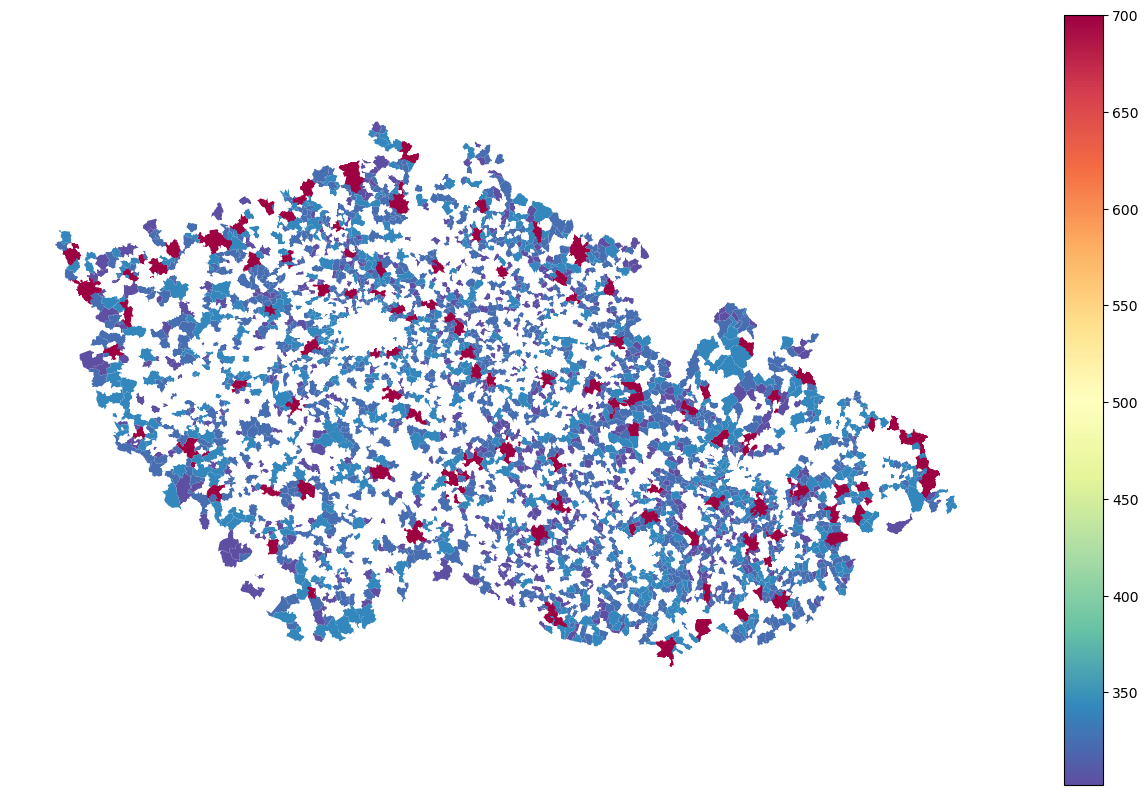

In [65]:
obce.plot("average_fee", figsize=(16,10),legend=True,cmap="Spectral_r",missing_kwds={"color": "white"},
).set_axis_off()

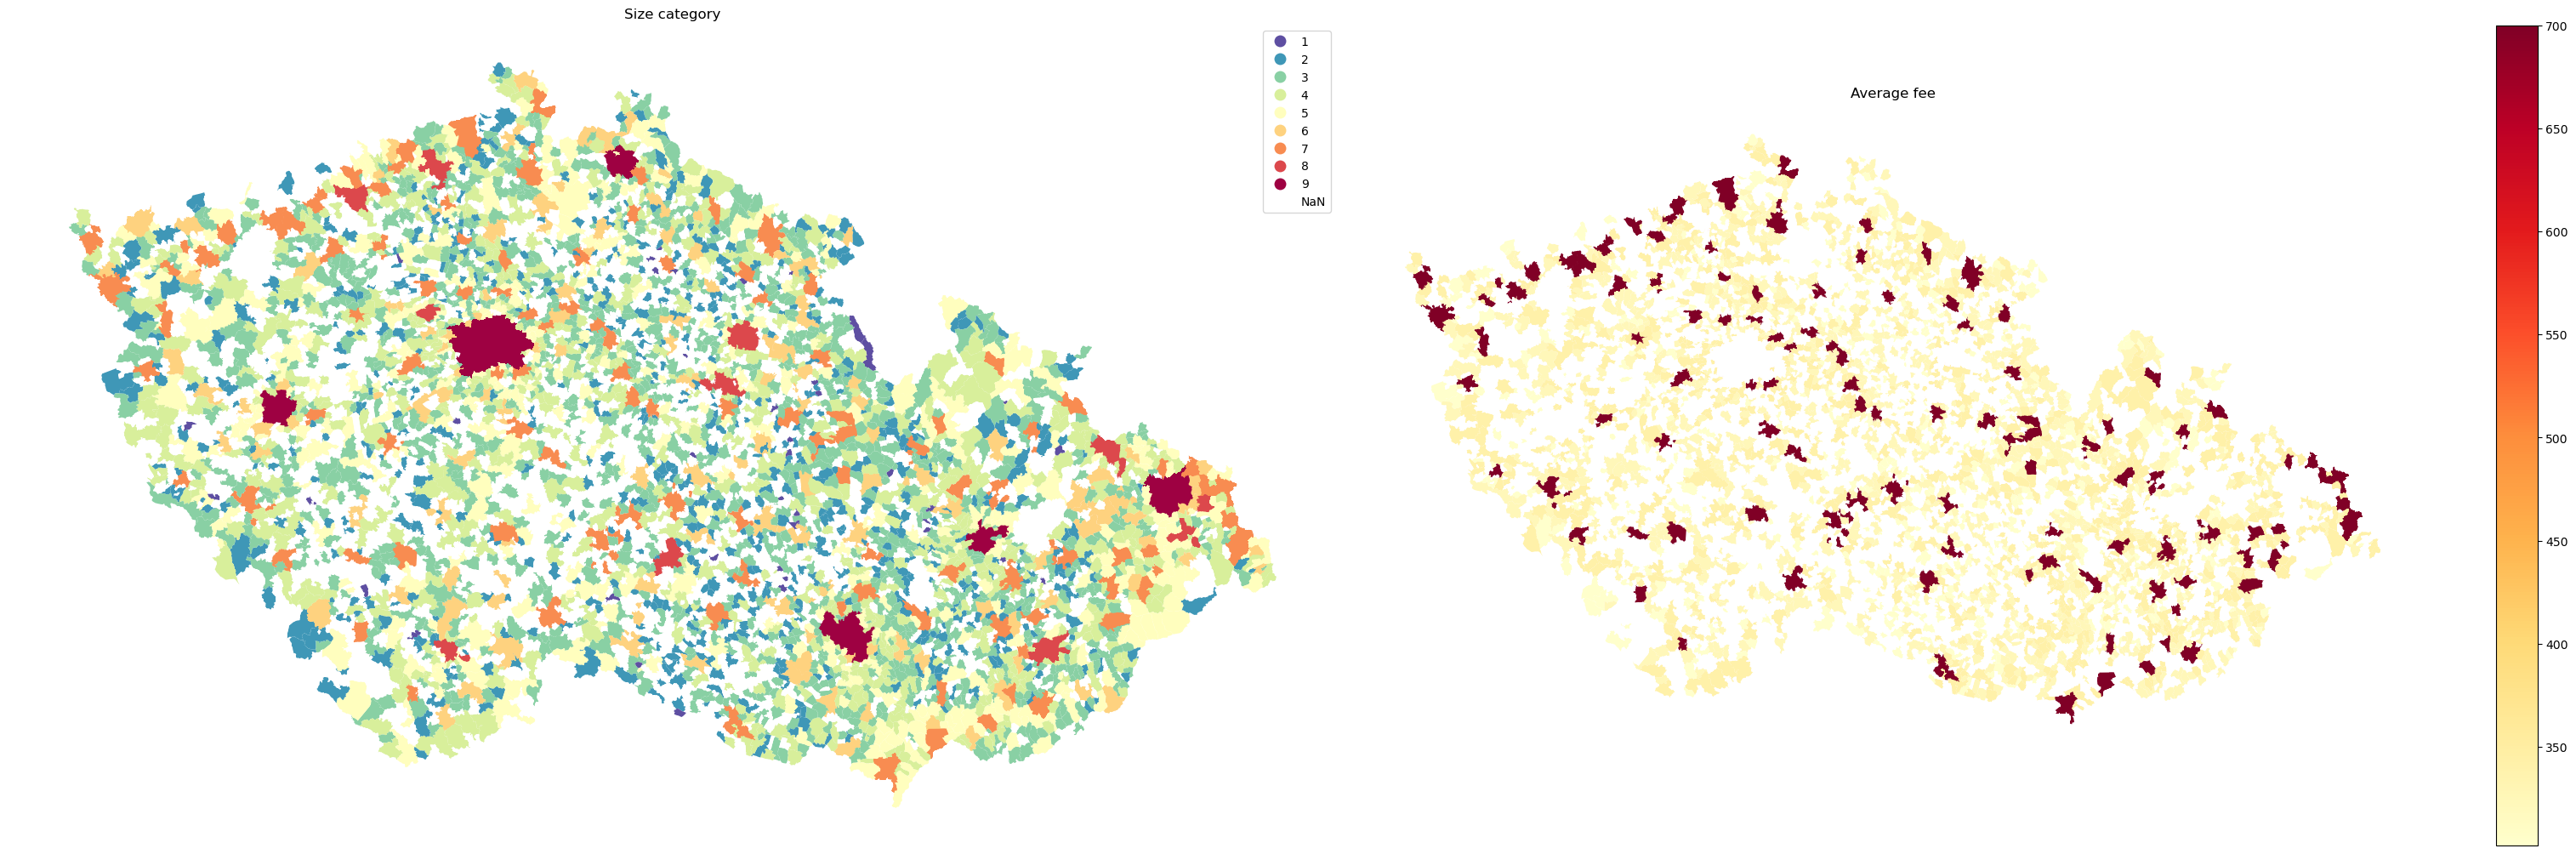

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))

obce.plot(
    column="size_category",
    ax=axes[0],
    legend=True,
    cmap="Spectral_r",
    missing_kwds={"color": "white"}
)
axes[0].set_title("Size category")
axes[0].set_axis_off()

obce.plot(
    column="average_fee",
    ax=axes[1],
    legend=True,
    cmap="YlOrRd",
    missing_kwds={"color": "white"}
)
axes[1].set_title("Average fee")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()
